# Case C : Hybrid (dt=0.5)

CONFIG: NX_FINE = 201 | H = 512 | DEPTH = 5 | EPOCHS = 2500 | USE_LBFGS = True
[data] training family size: 88
[data] generating fsolve targets ...
  gen 1/88 -> sin(1x)
  gen 2/88 -> cos(1x)
  gen 3/88 -> sin(2x)
  gen 4/88 -> cos(2x)
  gen 5/88 -> sin(3x)
  gen 6/88 -> cos(3x)
  gen 7/88 -> sin(4x)
  gen 8/88 -> cos(4x)
  gen 9/88 -> sin(5x)
  gen 10/88 -> cos(5x)
  gen 11/88 -> sin(6x)
  gen 12/88 -> cos(6x)
  gen 13/88 -> sin(7x)
  gen 14/88 -> cos(7x)
  gen 15/88 -> sin(8x)
  gen 16/88 -> cos(8x)
  gen 17/88 -> sin(9x)
  gen 18/88 -> cos(9x)
  gen 19/88 -> sin(10x)
  gen 20/88 -> cos(10x)
  gen 21/88 -> sin(11x)
  gen 22/88 -> cos(11x)
  gen 23/88 -> sin(12x)
  gen 24/88 -> cos(12x)
  gen 25/88 -> sin(1x+0.3)
  gen 26/88 -> sin(1x+0.7)
  gen 27/88 -> sin(1x+1.2)
  gen 28/88 -> sin(2x+0.3)
  gen 29/88 -> sin(2x+0.7)
  gen 30/88 -> sin(2x+1.2)
  gen 31/88 -> sin(3x+0.3)
  gen 32/88 -> sin(3x+0.7)
  gen 33/88 -> sin(3x+1.2)
  gen 34/88 -> sin(4x+0.3)
  gen 35/88 -> sin(4x+0.7)
  gen 

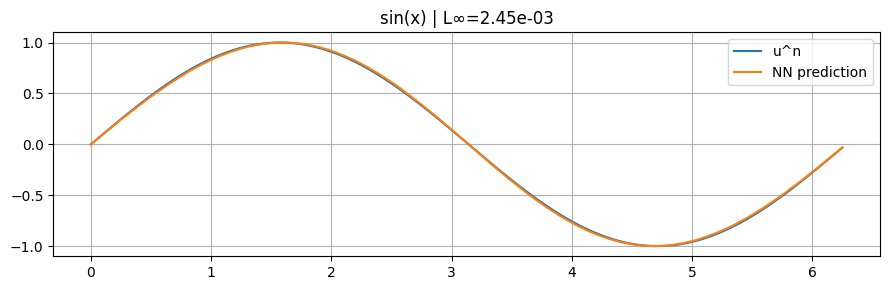

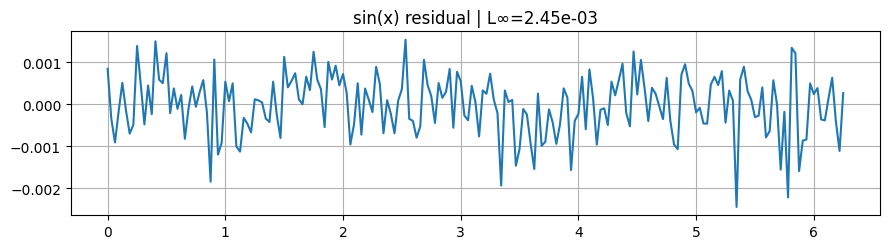

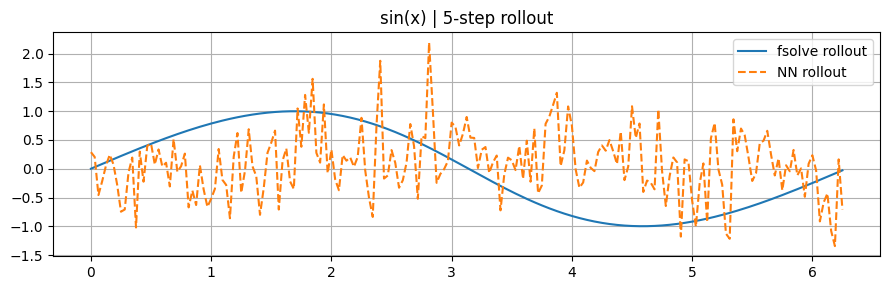


--- cos(14*x) ---
[test] cos(14*x)    | Residual | L∞=2.225e-03 | Mean=6.565e-04


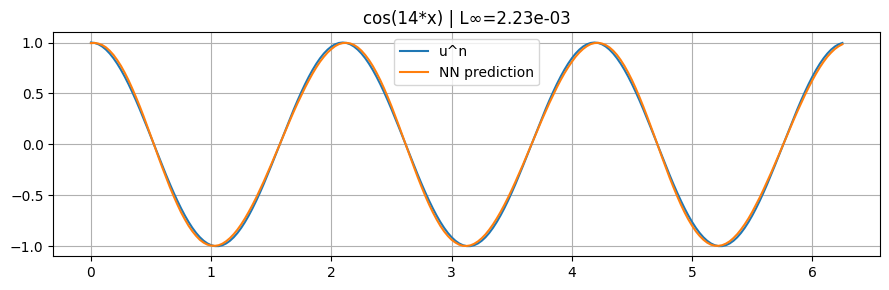

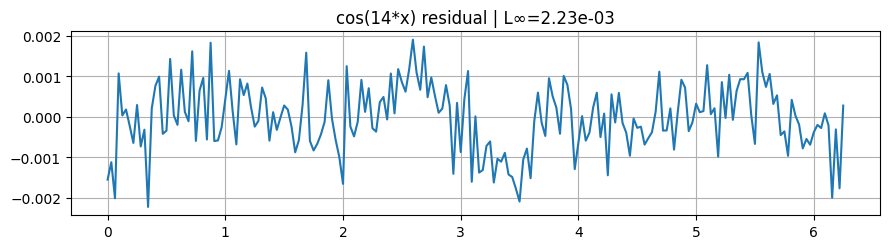

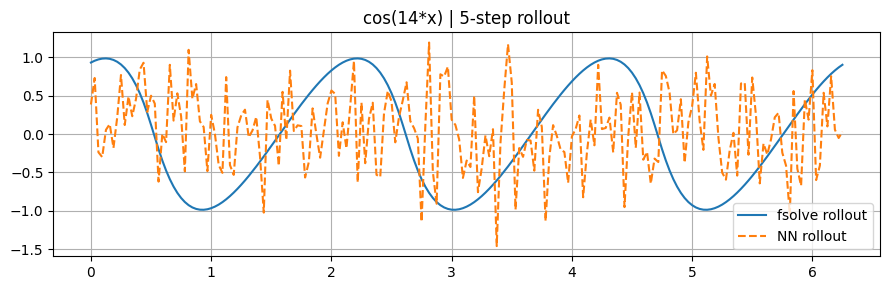


--- sin(x+0.3) ---
[test] sin(x+0.3)   | Residual | L∞=8.074e-03 | Mean=1.681e-03


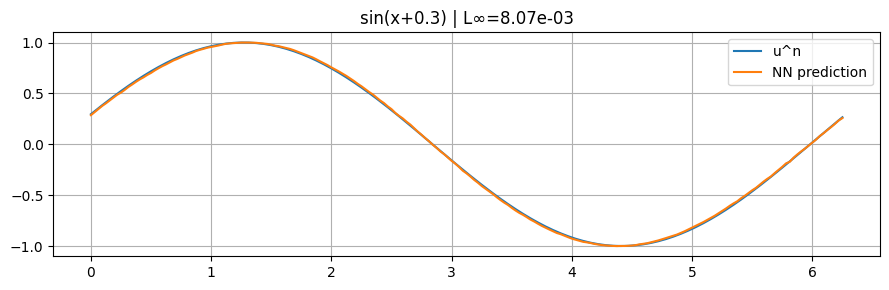

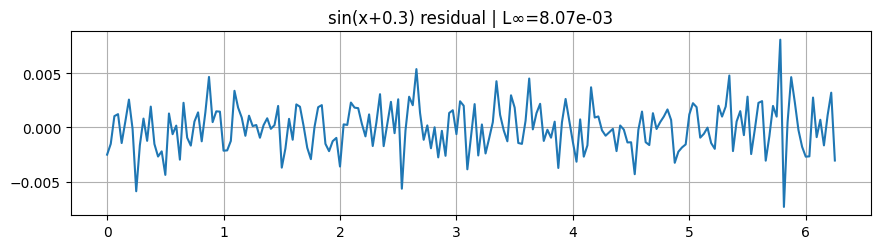

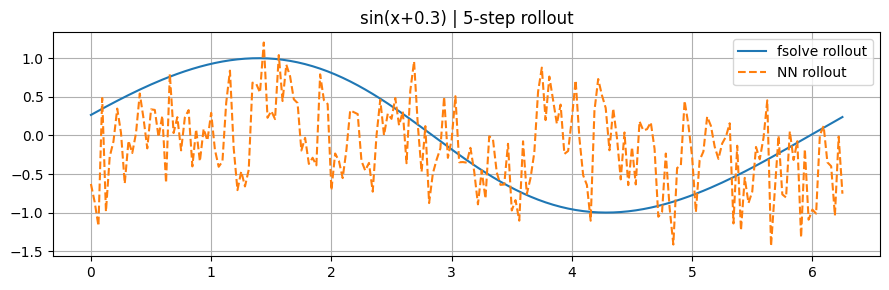


--- sin^2(x) ---
[test] sin^2(x)     | Residual | L∞=7.337e-04 | Mean=2.500e-04


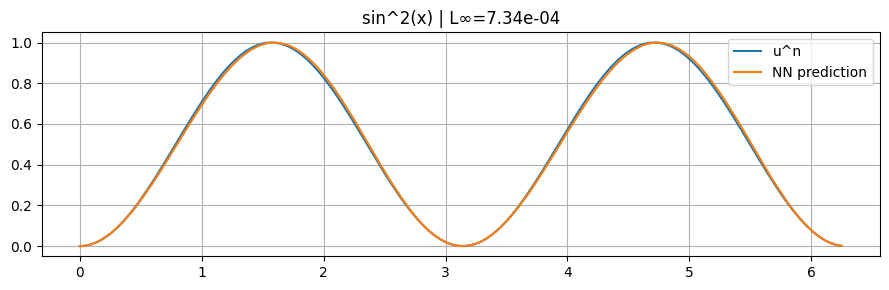

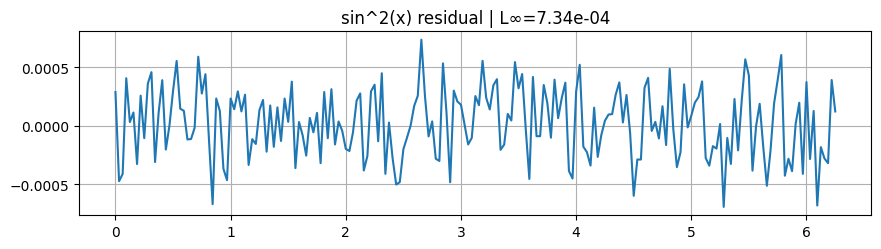

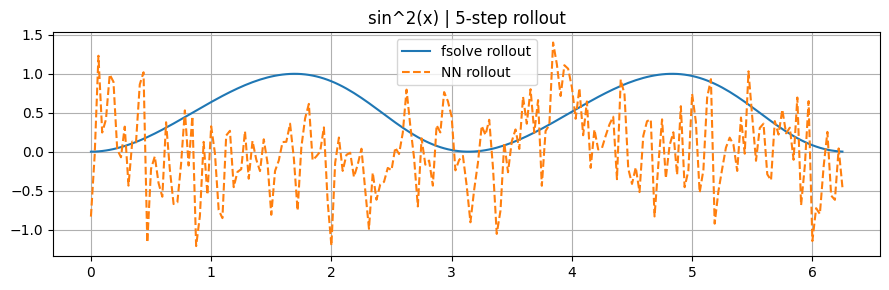


--- cos^3(x) ---
[test] cos^3(x)     | Residual | L∞=1.977e-03 | Mean=6.625e-04


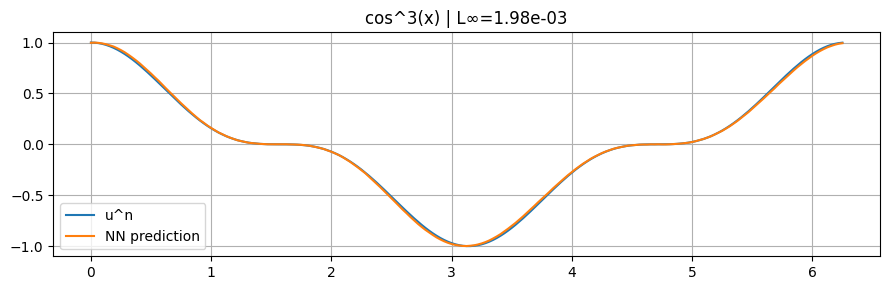

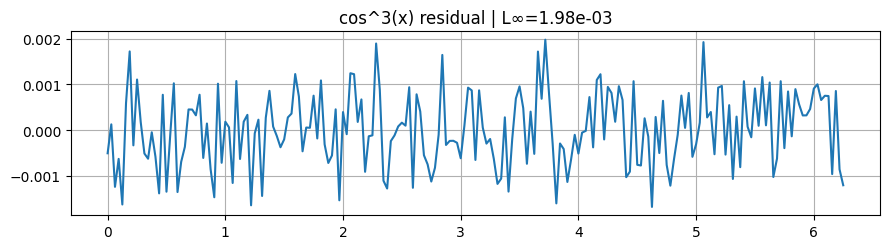

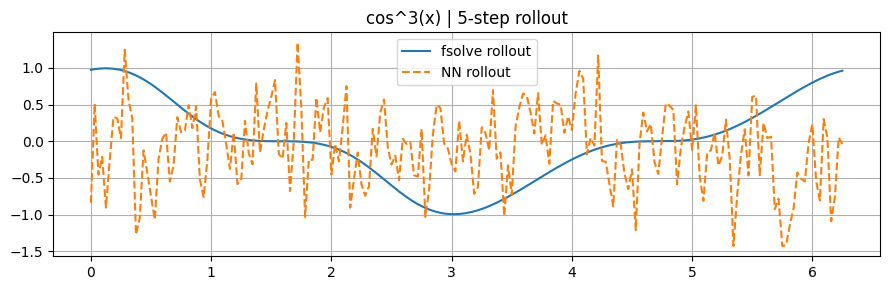


--- sin(2.5x) ---
[test] sin(2.5x)    | Residual | L∞=1.325e-03 | Mean=2.496e-04


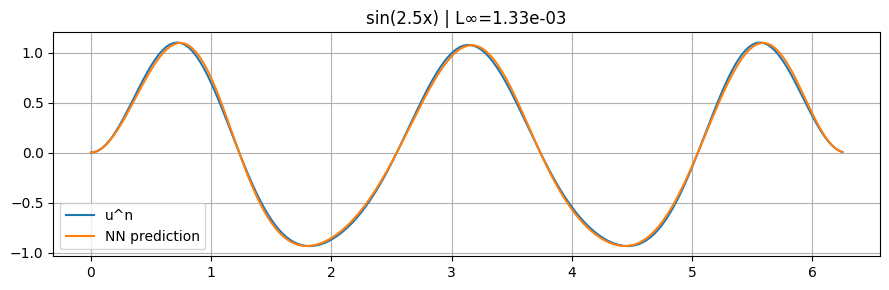

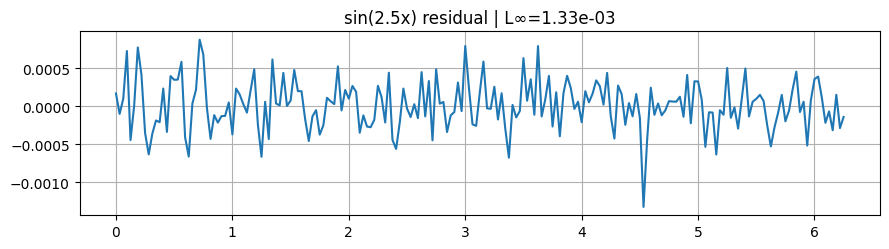

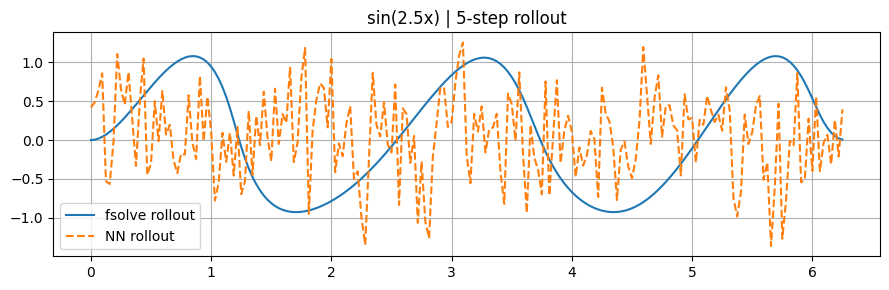


--- sin(x+1.2) ---
[test] sin(x+1.2)   | Residual | L∞=4.739e-03 | Mean=1.212e-03


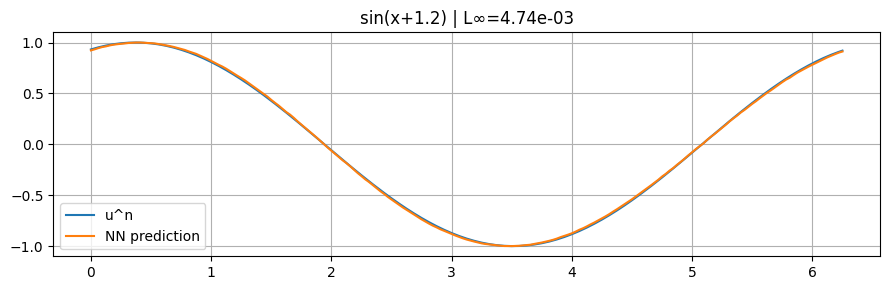

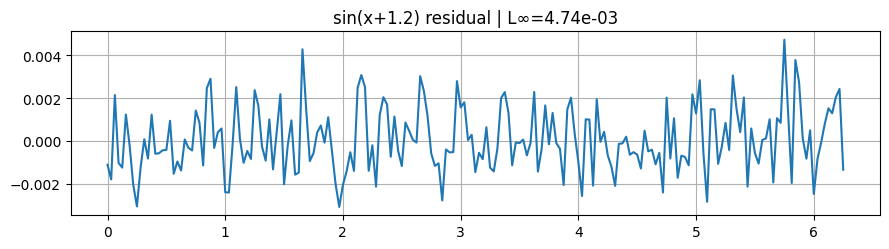

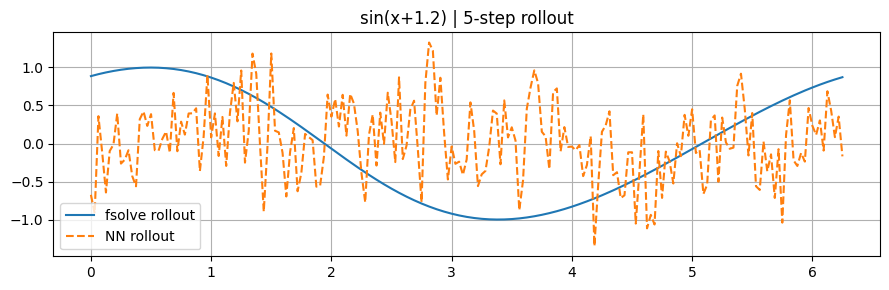

[summary] saved -> pinn_improved_demo\per_sample_summary_improved.csv
[plots] saved in -> pinn_improved_demo\plots

DONE.


In [2]:
import os, warnings, random
import numpy as np
import tensorflow as tf
from scipy.optimize import fsolve
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import tensorflow as tf

# CONFIG
TF64 = True
NX_COARSE = 11
NX_FINE   = 201
L = 2*np.pi
DT = 0.05

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Adam phase
EPOCHS       = 2500
LR           = 5e-5
SUP_WEIGHT   = 1.0      # data term
PHYS_WEIGHT  = 0.1/DT      # FIX1
BETA_L2      = 1e-6
GRAD_CLIP    = 1.0
PATIENCE     = 800

# L-BFGS phase
USE_LBFGS        = True
LBFGS_MAXITER    = 300
LBFGS_FTOL       = 1e-10

OUT_DIR   = "pinn_improved_demo"
os.makedirs(OUT_DIR, exist_ok=True)
PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(OUT_DIR, "nn_improved.weights.h5")
META_FILE    = os.path.join(OUT_DIR, "meta_improved.npz")
DATA_FILE    = os.path.join(OUT_DIR, "train_pairs_improved2.npz")

print("CONFIG:",
      "NX_FINE =", NX_FINE,
      "| H =", HIDDEN_UNITS,
      "| DEPTH =", DEPTH,
      "| EPOCHS =", EPOCHS,
      "| USE_LBFGS =", USE_LBFGS)

# precision/reproducibility
if TF64:
    tf.keras.backend.set_floatx('float64')
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('float64')
    except Exception:
        pass

np.random.seed(42); tf.random.set_seed(42); random.seed(42)
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")

# spectral differentiation
def generate_D_matrix(Nx, L):
    k = 2*np.pi*1j*np.fft.fftfreq(Nx, d=L/Nx)
    I = np.eye(Nx)
    D_fft = np.fft.ifft(k[:, None] * np.fft.fft(I, axis=0), axis=0)
    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)
D_tf = tf.constant(D_np, dtype=tf.float64)

def residual_np(y, u):
    return y - u + 0.25*DT*(D_np @ (y**2))

@tf.function
def residual_tf(y, u):
    y_sq = tf.square(y)
    dy_dx = tf.linalg.matmul(y_sq, tf.transpose(D_tf))
    return y - u + 0.25*DT*dy_dx

# grids
x_coarse = np.linspace(0, L, NX_COARSE, endpoint=False)
x_fine   = np.linspace(0, L, NX_FINE,   endpoint=False)

def fourier_interpolate(u_coarse, Nc, Nf):
    Uc = np.fft.fft(u_coarse)
    Uc_shift = np.fft.fftshift(Uc)
    pad_total = max(Nf-Nc, 0)
    pad_left  = pad_total//2
    pad_right = pad_total - pad_left
    Uc_padded_shift = np.pad(Uc_shift,
                             (pad_left, pad_right),
                             mode="constant",
                             constant_values=0.0)
    Uc_padded = np.fft.ifftshift(Uc_padded_shift)
    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)
    return u_fine.real

# fsolve
def compute_y1_fsolve(un):
    un = np.asarray(un, dtype=np.float64)
    N = un.size
    def F(y):
        return y - un + 0.25*DT*(D_np @ (y**2))
    def J(y):
        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))
    y0 = un.copy()
    y_sol, info, ier, msg = fsolve(F, y0, fprime=J,
                                   xtol=1e-12, maxfev=30000,
                                   full_output=True)
    if ier != 1:
        print("[warn fsolve] ier", ier, msg)
    return y_sol.astype(np.float64)

# training funct un
def make_rich_family():
    fns = []
    
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]
    # random linear combos of sines/cosines for more variety
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns = make_rich_family()
print("[data] training family size:", len(train_fns))

# data generation
if os.path.exists(DATA_FILE):
    dd = np.load(DATA_FILE, allow_pickle=True)
    un_train = dd["un"]
    y1_train = dd["y1"]
    print("[data] loaded training pairs:", un_train.shape)
else:
    print("[data] generating fsolve targets ...")
    U_list, Y_list = [], []
    for i, (name, fn) in enumerate(train_fns):
        u_c = fn(x_coarse)
        u_f = fourier_interpolate(u_c, NX_COARSE, NX_FINE)
        y1  = compute_y1_fsolve(u_f)
        U_list.append(u_f)
        Y_list.append(y1)
        print(f"  gen {i+1}/{len(train_fns)} -> {name}")
    un_train = np.array(U_list, dtype=np.float64)
    y1_train = np.array(Y_list, dtype=np.float64)
    np.savez(DATA_FILE, un=un_train, y1=y1_train)
    print("[data] saved ->", DATA_FILE)

print("[data] un_train shape:", un_train.shape, "y1_train shape:", y1_train.shape)

# features
def build_features(un_batch):
    mag = np.abs(np.fft.fft(un_batch, axis=-1))[:, :NX_FINE//2+1]

    mag = 0.2 * mag  

    return np.concatenate([un_batch, mag], axis=-1)

X_raw = build_features(un_train)

feat_mean = np.mean(X_raw, axis=0)
feat_std  = np.std(X_raw, axis=0) + 1e-12
X_norm = (X_raw - feat_mean) / feat_std

print("[features] using [u, |FFT(u)|] with normalization.")
print("[features] X_norm shape:", X_norm.shape)

# SIREN model 
class SineDense(tf.keras.layers.Layer):
    def __init__(self, units, w0=30.0, is_first=False, **kwargs):
        super().__init__(dtype=tf.float64, **kwargs)
        self.units = int(units)
        self.w0 = float(w0)
        self.is_first = bool(is_first)
    def build(self, input_shape):
        in_dim = int(input_shape[-1])
        bound = (1.0/in_dim) if self.is_first else (np.sqrt(6.0/in_dim)/self.w0)
        w_init = tf.keras.initializers.RandomUniform(minval=-bound, maxval=bound)
        b_init = tf.keras.initializers.Zeros()
        self.W = self.add_weight(name="W", shape=(in_dim, self.units),
                                 dtype=tf.float64, initializer=w_init, trainable=True)
        self.b = self.add_weight(name="b", shape=(self.units,),
                                 dtype=tf.float64, initializer=b_init, trainable=True)
    def call(self, x):
        return tf.sin(self.w0*(tf.matmul(x, self.W) + self.b))

def build_model(output_dim, input_dim,
                hidden_units=512, depth=5,
                w0=15.0, use_siren=True):
    inputs = tf.keras.Input(shape=(input_dim,), dtype=tf.float64)
    h = inputs
    if use_siren:
        h = SineDense(hidden_units, w0=w0, is_first=True)(h)
        for _ in range(depth-1):
            h = SineDense(hidden_units, w0=w0, is_first=False)(h)
    else:
        h = tf.keras.layers.Dense(hidden_units, activation="gelu",
                                  dtype=tf.float64)(h)
        for _ in range(depth-1):
            h = tf.keras.layers.Dense(hidden_units, activation="gelu",
                                      dtype=tf.float64)(h)
    out = tf.keras.layers.Dense(output_dim, dtype=tf.float64)(h)
    return tf.keras.Model(inputs=inputs, outputs=out)

input_dim = X_norm.shape[1]
model = build_model(NX_FINE, input_dim,
                    HIDDEN_UNITS, DEPTH,
                    SIREN_W0, USE_SIREN)
_ = model(tf.zeros((1, input_dim), dtype=tf.float64))
print("[model] params:", model.count_params())

# training tensors
X_tf     = tf.convert_to_tensor(X_norm,   dtype=tf.float64)
U_tf     = tf.convert_to_tensor(un_train, dtype=tf.float64)
Ytrue_tf = tf.convert_to_tensor(y1_train, dtype=tf.float64)

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

def l2_regularizer(weights):
    return tf.add_n([tf.nn.l2_loss(v) for v in weights])

# Adam training
print("\n PHASE 1: Adam (supervised + physics)")
best_total = np.inf
best_phys  = np.inf
wait = 0

for epoch in range(1, EPOCHS+1):
    with tf.GradientTape() as tape:
        y_pred = model(X_tf, training=True)
        sup_loss = tf.reduce_mean(tf.square(y_pred - Ytrue_tf))
        r = residual_tf(y_pred, U_tf)
        phys_loss = tf.reduce_mean(tf.square(r))
        linf = tf.reduce_max(tf.abs(r))
        reg = BETA_L2 * l2_regularizer(model.trainable_variables)
        total = SUP_WEIGHT*sup_loss + PHYS_WEIGHT*phys_loss + reg

    grads = tape.gradient(total, model.trainable_variables)
    grads = [tf.clip_by_norm(g, GRAD_CLIP) for g in grads]
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | Total: {float(total):.3e} | "
              f"Sup: {float(sup_loss):.3e} | Phys: {float(phys_loss):.3e} | "
              f"L∞(phys): {float(linf):.3e} | Reg: {float(reg):.3e}")

    tot_val = float(total.numpy())
    if tot_val < best_total - 1e-12:
        best_total = tot_val
        best_phys  = float(phys_loss.numpy())
        wait = 0
        model.save_weights(WEIGHTS_FILE)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"[early stop] at epoch {epoch}")
            break

print(f"[Adam] best_total = {best_total:.6e}, best_phys = {best_phys:.6e}")
print("[Adam] saved best weights ->", WEIGHTS_FILE)

# L-BFGS
if USE_LBFGS:
    print("\n=== PHASE 2: L-BFGS polish (same loss) ===")
    # reload best Adam weights as starting point
    model.load_weights(WEIGHTS_FILE)

    var_list = model.trainable_variables
    shapes = [v.shape for v in var_list]
    sizes  = [int(np.prod(s)) for s in shapes]
    total_params = sum(sizes)

    def pack_weights():
        return np.concatenate([v.numpy().ravel() for v in var_list])

    def unpack_weights(theta):
        offset = 0
        for v, s, sz in zip(var_list, shapes, sizes):
            chunk = theta[offset:offset+sz]
            v.assign(chunk.reshape(s))
            offset += sz

    @tf.function
    def loss_and_grads_tf():
        with tf.GradientTape() as tape:
            y_pred = model(X_tf, training=True)
            sup_loss = tf.reduce_mean(tf.square(y_pred - Ytrue_tf))
            r = residual_tf(y_pred, U_tf)
            phys_loss = tf.reduce_mean(tf.square(r))
            reg = BETA_L2 * l2_regularizer(model.trainable_variables)
            total = SUP_WEIGHT*sup_loss + PHYS_WEIGHT*phys_loss + reg
        grads = tape.gradient(total, var_list)
        return total, grads, sup_loss, phys_loss

    def lbfgs_objective(theta):
        unpack_weights(theta)
        total_tf, grads_tf, sup_tf, phys_tf = loss_and_grads_tf()
        loss_val = float(total_tf.numpy())
        grad_vec = np.concatenate([g.numpy().ravel() for g in grads_tf])
        return loss_val, grad_vec

    theta0 = pack_weights()
    print("[L-BFGS] starting from Adam weights; n_params =", total_params)

    result = minimize(lbfgs_objective, theta0, jac=True,
                      method='L-BFGS-B',
                      options={'maxiter': LBFGS_MAXITER,
                               'ftol': LBFGS_FTOL,
                               'maxcor': 50,
                               'iprint': 1})

    print("[L-BFGS] success:", result.success, "| message:", result.message)
    unpack_weights(result.x)
    # final losses
    total_tf, _, sup_tf, phys_tf = loss_and_grads_tf()
    print(f"[L-BFGS] final total: {float(total_tf.numpy()):.3e} | "
          f"Sup: {float(sup_tf.numpy()):.3e} | Phys: {float(phys_tf.numpy()):.3e}")
    model.save_weights(WEIGHTS_FILE)
    print("[L-BFGS] saved polished weights ->", WEIGHTS_FILE)

# save meta info
np.savez(META_FILE,
         NX_FINE=NX_FINE, NX_COARSE=NX_COARSE, DT=DT, L=L,
         USE_SIREN=np.array([USE_SIREN]),
         HIDDEN_UNITS=HIDDEN_UNITS, DEPTH=DEPTH, SIREN_W0=SIREN_W0,
         feat_mean=feat_mean, feat_std=feat_std)
print("[meta] saved ->", META_FILE)


# TESTING
print("\n TEST & DIAGNOSTICS (NN-only + rollout)")

model.load_weights(WEIGHTS_FILE)
print("[test] loaded NN-only weights")

def safe_filename(name):
    return (name.replace("(", "")
                .replace(")", "")
                .replace("*", "")
                .replace("^", "")
                .replace("+", "")
                .replace("-", "")
                .replace(" ", "_"))


# Features

def build_feat_single(u_f):
    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]
    mag = 0.2 * mag  
    feats = np.concatenate([u_f, mag])
    return ((feats - feat_mean) / feat_std)[None, :]


# Rollout

def rollout_nn(u0, steps=5):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(steps):
        feat = build_feat_single(u)
        y = model(tf.constant(feat, dtype=tf.float64),
                  training=False).numpy()[0]
        u = y.copy()
        traj.append(u.copy())
    return traj


# Test functions

tests = [
    ("sin(x)"      , lambda x: np.sin(x)),
    ("cos(14*x)"   , lambda x: np.cos(14*x)),
    ("sin(x+0.3)"  , lambda x: np.sin(x+0.3)),
    ("sin^2(x)"    , lambda x: np.sin(x)**2),
    ("cos^3(x)"    , lambda x: np.cos(x)**3),
    ("sin(2.5x)"   , lambda x: np.sin(2.5*x)),
    ("sin(x+1.2)"  , lambda x: np.sin(x+1.2))
]

summary = {}


# Testing

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    # initial condition
    uf = fourier_interpolate(fn(x_coarse), NX_COARSE, NX_FINE)

    # NN prediction
    feat = build_feat_single(uf)
    y_pred = model(tf.constant(feat, dtype=tf.float64),
                   training=False).numpy()[0]

    # physics residual
    r = residual_np(y_pred, uf)
    Linf = float(np.max(np.abs(r)))
    Mean = float(np.mean(np.abs(r)))

    print(f"[test] {name:12s} | Residual | L∞={Linf:.3e} | Mean={Mean:.3e}")

    xs = x_fine

    
    # Solution plot
    
    plt.figure(figsize=(9,3))
    plt.plot(xs, uf, label="u^n")
    plt.plot(xs, y_pred, label="NN prediction")
    plt.legend()
    plt.title(f"{name} | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_nn.png"), dpi=150)
    plt.show()

    
    # Residual plot
    
    plt.figure(figsize=(9,2.6))
    plt.plot(xs, r)
    plt.title(f"{name} residual | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_res.png"), dpi=150)
    plt.show()

    
    # 5-step rollout comparison
    steps = 5

    traj_nn = rollout_nn(uf, steps)

    # fsolve rollout
    traj_fs = [uf.copy()]
    tmp = uf.copy()
    for _ in range(steps):
        tmp = compute_y1_fsolve(tmp)
        traj_fs.append(tmp.copy())

    plt.figure(figsize=(9,3))
    plt.plot(xs, traj_fs[-1], label="fsolve rollout")
    plt.plot(xs, traj_nn[-1], "--", label="NN rollout")
    plt.legend()
    plt.title(f"{name} | {steps}-step rollout")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_rollout.png"), dpi=150)
    plt.show()

    summary[name] = (Linf, Mean)


# Save summary
import csv

csv_path = os.path.join(OUT_DIR, "per_sample_summary_improved.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["name", "Linf", "Mean"]case
    for k, v in summary.items():
        w.writerow([k, v[0], v[1]])

print("[summary] saved ->", csv_path)
print("[plots] saved in ->", PLOTS_DIR)

print("\nDONE.")

# case 2 dt=0.01/2 = 0.005

CONFIG: NX_FINE = 201 | H = 512 | DEPTH = 5 | EPOCHS = 2500 | USE_LBFGS = True
[data] training family size: 88
[data] generating fsolve targets ...
  gen 1/88 -> sin(1x)
  gen 2/88 -> cos(1x)
  gen 3/88 -> sin(2x)
  gen 4/88 -> cos(2x)
  gen 5/88 -> sin(3x)
  gen 6/88 -> cos(3x)
  gen 7/88 -> sin(4x)
  gen 8/88 -> cos(4x)
  gen 9/88 -> sin(5x)
  gen 10/88 -> cos(5x)
  gen 11/88 -> sin(6x)
  gen 12/88 -> cos(6x)
  gen 13/88 -> sin(7x)
  gen 14/88 -> cos(7x)
  gen 15/88 -> sin(8x)
  gen 16/88 -> cos(8x)
  gen 17/88 -> sin(9x)
  gen 18/88 -> cos(9x)
  gen 19/88 -> sin(10x)
  gen 20/88 -> cos(10x)
  gen 21/88 -> sin(11x)
  gen 22/88 -> cos(11x)
  gen 23/88 -> sin(12x)
  gen 24/88 -> cos(12x)
  gen 25/88 -> sin(1x+0.3)
  gen 26/88 -> sin(1x+0.7)
  gen 27/88 -> sin(1x+1.2)
  gen 28/88 -> sin(2x+0.3)
  gen 29/88 -> sin(2x+0.7)
  gen 30/88 -> sin(2x+1.2)
  gen 31/88 -> sin(3x+0.3)
  gen 32/88 -> sin(3x+0.7)
  gen 33/88 -> sin(3x+1.2)
  gen 34/88 -> sin(4x+0.3)
  gen 35/88 -> sin(4x+0.7)
  gen 

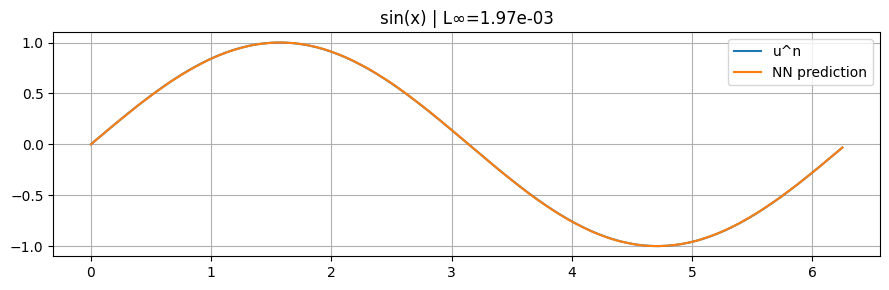

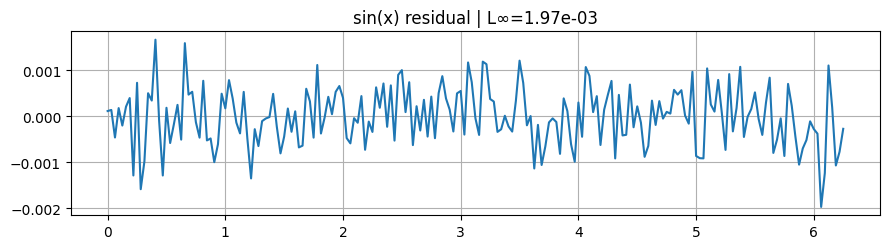

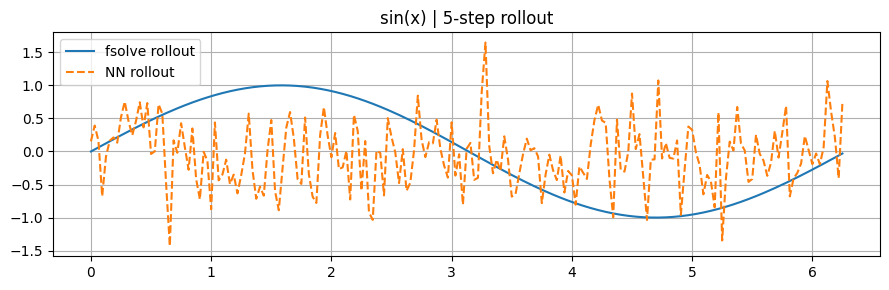


--- cos(14*x) ---
[test] cos(14*x)    | Residual | L∞=1.712e-03 | Mean=5.404e-04


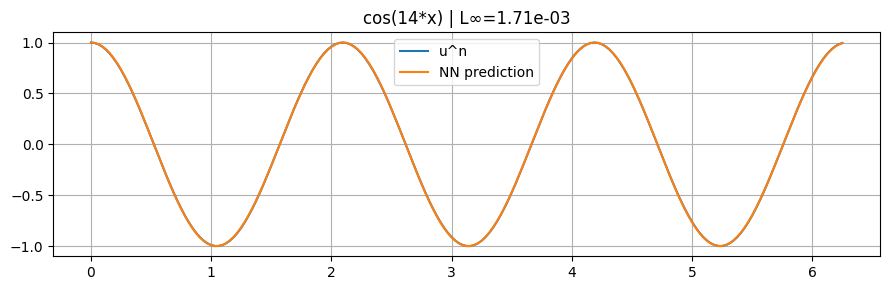

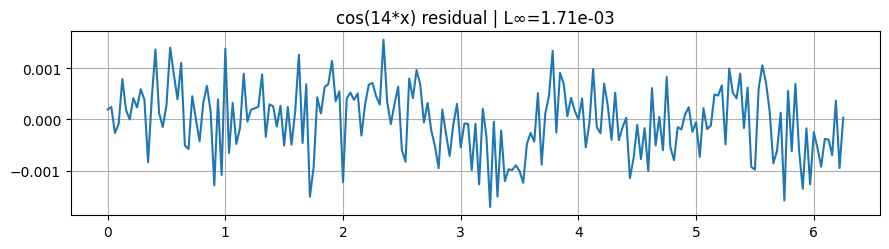

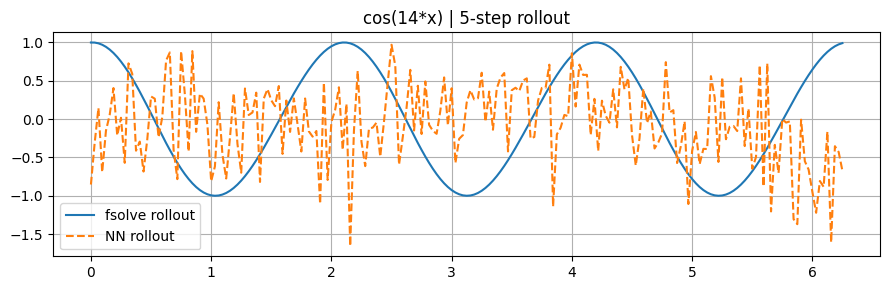


--- sin(x+0.3) ---
[test] sin(x+0.3)   | Residual | L∞=4.434e-03 | Mean=1.316e-03


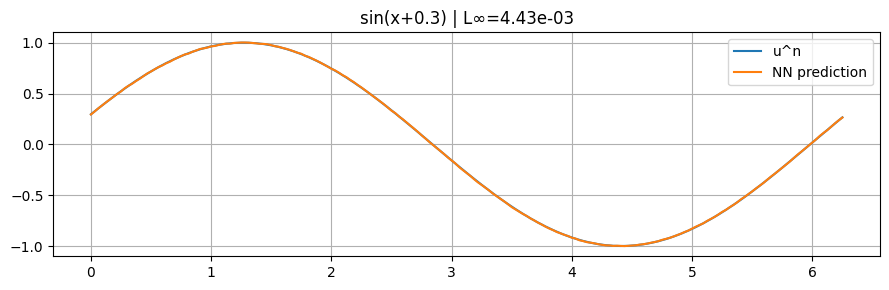

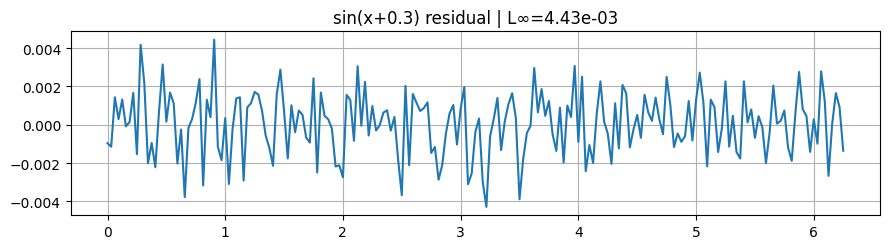

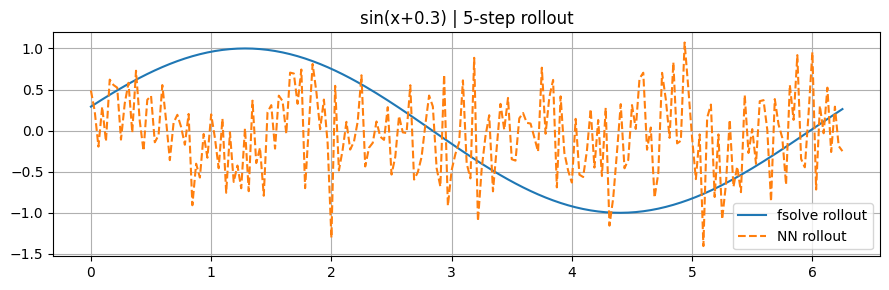


--- sin^2(x) ---
[test] sin^2(x)     | Residual | L∞=7.256e-04 | Mean=1.842e-04


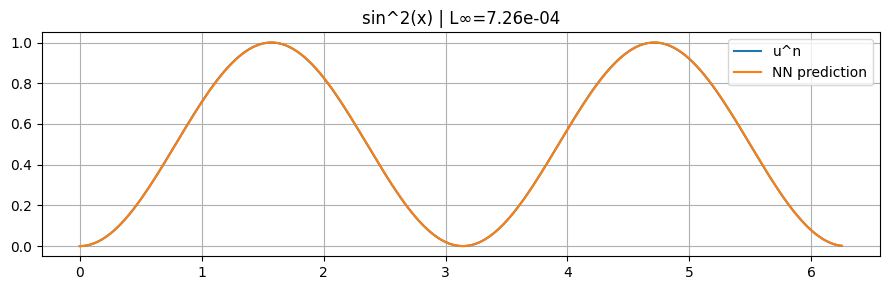

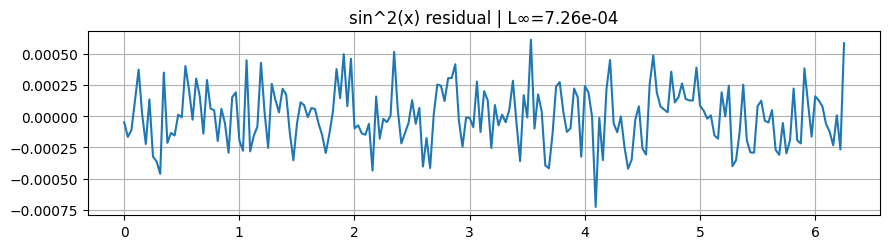

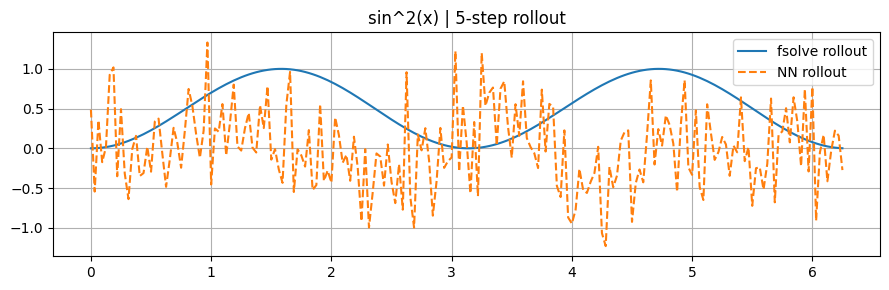


--- cos^3(x) ---
[test] cos^3(x)     | Residual | L∞=2.272e-03 | Mean=5.312e-04


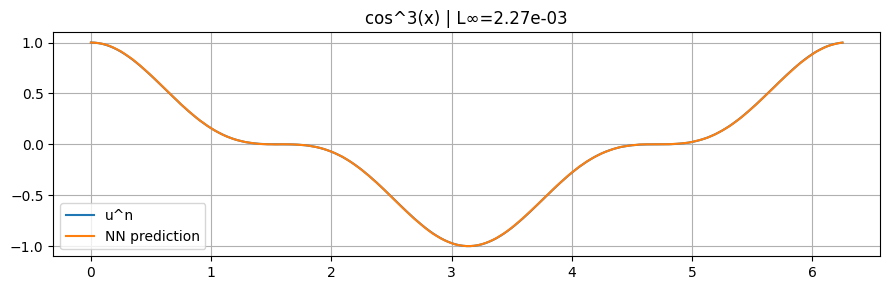

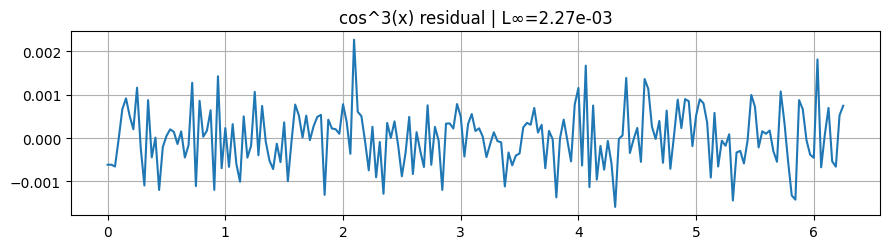

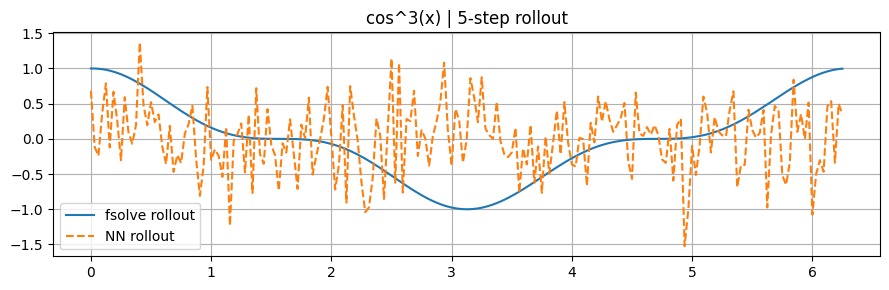


--- sin(2.5x) ---
[test] sin(2.5x)    | Residual | L∞=6.276e-04 | Mean=1.910e-04


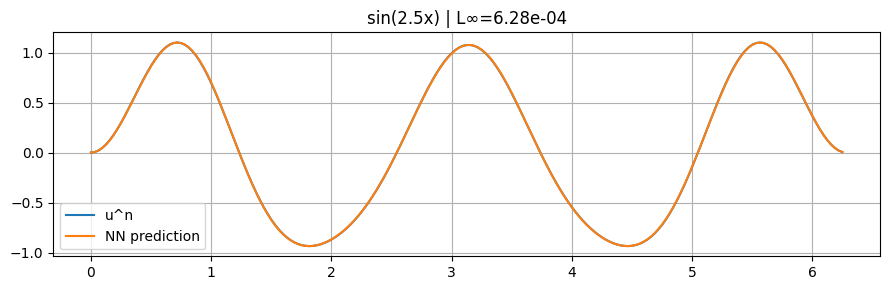

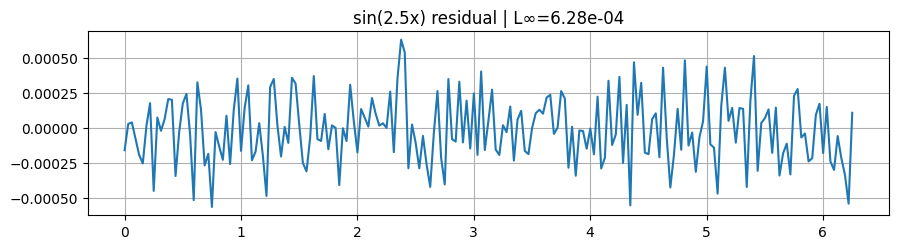

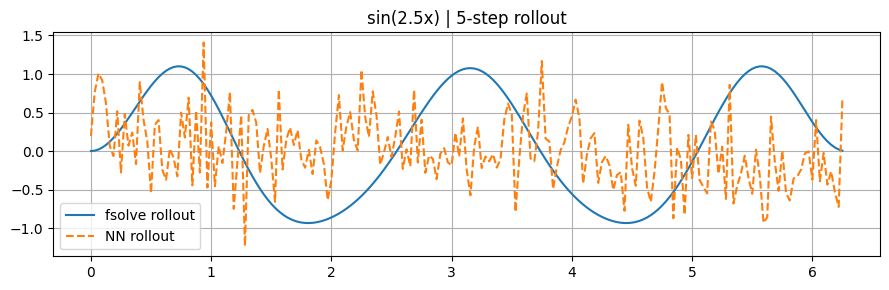


--- sin(x+1.2) ---
[test] sin(x+1.2)   | Residual | L∞=3.977e-03 | Mean=8.230e-04


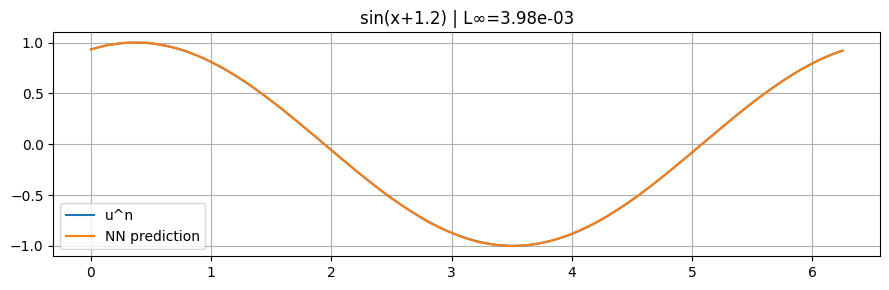

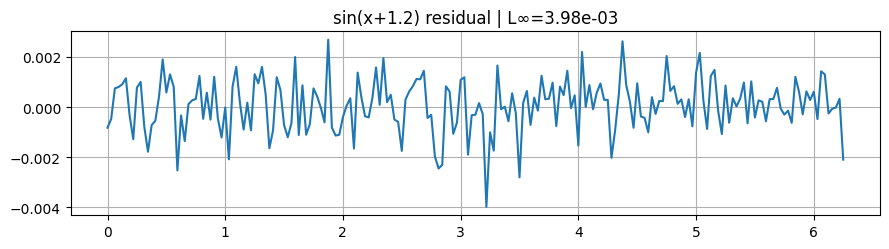

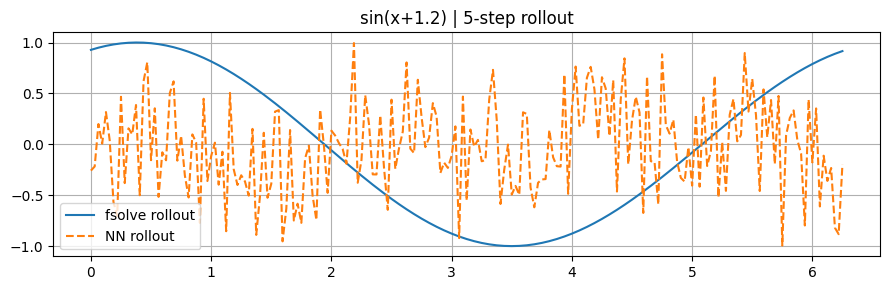

[summary] saved -> pinn_improved_demo\per_sample_summary_improved.csv
[plots] saved in -> pinn_improved_demo\plots

DONE.


In [3]:
import os, warnings, random
import numpy as np
import tensorflow as tf
from scipy.optimize import fsolve
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import tensorflow as tf

# CONFIG
TF64 = True
NX_COARSE = 11
NX_FINE   = 201
L = 2*np.pi
DT = 0.005

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Adam phase
EPOCHS       = 2500
LR           = 5e-5
SUP_WEIGHT   = 1.0      
PHYS_WEIGHT  = 0.1/DT      
BETA_L2      = 1e-6
GRAD_CLIP    = 1.0
PATIENCE     = 800

# L-BFGS phase
USE_LBFGS        = True
LBFGS_MAXITER    = 300
LBFGS_FTOL       = 1e-10

OUT_DIR   = "pinn_improved_demo"
os.makedirs(OUT_DIR, exist_ok=True)
PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(OUT_DIR, "nn_improved.weights.h5")
META_FILE    = os.path.join(OUT_DIR, "meta_improved.npz")
DATA_FILE    = os.path.join(OUT_DIR, "train_pairs_improved0.005.npz")

print("CONFIG:",
      "NX_FINE =", NX_FINE,
      "| H =", HIDDEN_UNITS,
      "| DEPTH =", DEPTH,
      "| EPOCHS =", EPOCHS,
      "| USE_LBFGS =", USE_LBFGS)

# precision / reproducibility
if TF64:
    tf.keras.backend.set_floatx('float64')
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('float64')
    except Exception:
        pass

np.random.seed(42); tf.random.set_seed(42); random.seed(42)
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")

# spectral differentiation
def generate_D_matrix(Nx, L):
    k = 2*np.pi*1j*np.fft.fftfreq(Nx, d=L/Nx)
    I = np.eye(Nx)
    D_fft = np.fft.ifft(k[:, None] * np.fft.fft(I, axis=0), axis=0)
    return D_fft.real

D_np = generate_D_matrix(NX_FINE, L)
D_tf = tf.constant(D_np, dtype=tf.float64)

def residual_np(y, u):
    return y - u + 0.25*DT*(D_np @ (y**2))

@tf.function
def residual_tf(y, u):
    y_sq = tf.square(y)
    dy_dx = tf.linalg.matmul(y_sq, tf.transpose(D_tf))
    return y - u + 0.25*DT*dy_dx

# grids
x_coarse = np.linspace(0, L, NX_COARSE, endpoint=False)
x_fine   = np.linspace(0, L, NX_FINE,   endpoint=False)

def fourier_interpolate(u_coarse, Nc, Nf):
    Uc = np.fft.fft(u_coarse)
    Uc_shift = np.fft.fftshift(Uc)
    pad_total = max(Nf-Nc, 0)
    pad_left  = pad_total//2
    pad_right = pad_total - pad_left
    Uc_padded_shift = np.pad(Uc_shift,
                             (pad_left, pad_right),
                             mode="constant",
                             constant_values=0.0)
    Uc_padded = np.fft.ifftshift(Uc_padded_shift)
    u_fine = np.fft.ifft(Uc_padded) * (Nf/Nc)
    return u_fine.real

# F solver
def compute_y1_fsolve(un):
    un = np.asarray(un, dtype=np.float64)
    N = un.size
    def F(y):
        return y - un + 0.25*DT*(D_np @ (y**2))
    def J(y):
        return np.eye(N) + 0.5*DT*(D_np @ np.diag(y))
    y0 = un.copy()
    y_sol, info, ier, msg = fsolve(F, y0, fprime=J,
                                   xtol=1e-12, maxfev=30000,
                                   full_output=True)
    if ier != 1:
        print("[warn fsolve] ier", ier, msg)
    return y_sol.astype(np.float64)

# training funct un
def make_rich_family():
    fns = []

    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]
    # random linear combos of sines/cosines for more varietY
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns = make_rich_family()
print("[data] training family size:", len(train_fns))

# data generation
if os.path.exists(DATA_FILE):
    dd = np.load(DATA_FILE, allow_pickle=True)
    un_train = dd["un"]
    y1_train = dd["y1"]
    print("[data] loaded training pairs:", un_train.shape)
else:
    print("[data] generating fsolve targets ...")
    U_list, Y_list = [], []
    for i, (name, fn) in enumerate(train_fns):
        u_c = fn(x_coarse)
        u_f = fourier_interpolate(u_c, NX_COARSE, NX_FINE)
        y1  = compute_y1_fsolve(u_f)
        U_list.append(u_f)
        Y_list.append(y1)
        print(f"  gen {i+1}/{len(train_fns)} -> {name}")
    un_train = np.array(U_list, dtype=np.float64)
    y1_train = np.array(Y_list, dtype=np.float64)
    np.savez(DATA_FILE, un=un_train, y1=y1_train)
    print("[data] saved ->", DATA_FILE)

print("[data] un_train shape:", un_train.shape, "y1_train shape:", y1_train.shape)

# features
def build_features(un_batch):
    mag = np.abs(np.fft.fft(un_batch, axis=-1))[:, :NX_FINE//2+1]

    mag = 0.2 * mag   

    return np.concatenate([un_batch, mag], axis=-1)

X_raw = build_features(un_train)

feat_mean = np.mean(X_raw, axis=0)
feat_std  = np.std(X_raw, axis=0) + 1e-12
X_norm = (X_raw - feat_mean) / feat_std

print("[features] using [u, |FFT(u)|] with normalization.")
print("[features] X_norm shape:", X_norm.shape)

# SIREN model 
class SineDense(tf.keras.layers.Layer):
    def __init__(self, units, w0=30.0, is_first=False, **kwargs):
        super().__init__(dtype=tf.float64, **kwargs)
        self.units = int(units)
        self.w0 = float(w0)
        self.is_first = bool(is_first)
    def build(self, input_shape):
        in_dim = int(input_shape[-1])
        bound = (1.0/in_dim) if self.is_first else (np.sqrt(6.0/in_dim)/self.w0)
        w_init = tf.keras.initializers.RandomUniform(minval=-bound, maxval=bound)
        b_init = tf.keras.initializers.Zeros()
        self.W = self.add_weight(name="W", shape=(in_dim, self.units),
                                 dtype=tf.float64, initializer=w_init, trainable=True)
        self.b = self.add_weight(name="b", shape=(self.units,),
                                 dtype=tf.float64, initializer=b_init, trainable=True)
    def call(self, x):
        return tf.sin(self.w0*(tf.matmul(x, self.W) + self.b))

def build_model(output_dim, input_dim,
                hidden_units=512, depth=5,
                w0=15.0, use_siren=True):
    inputs = tf.keras.Input(shape=(input_dim,), dtype=tf.float64)
    h = inputs
    if use_siren:
        h = SineDense(hidden_units, w0=w0, is_first=True)(h)
        for _ in range(depth-1):
            h = SineDense(hidden_units, w0=w0, is_first=False)(h)
    else:
        h = tf.keras.layers.Dense(hidden_units, activation="gelu",
                                  dtype=tf.float64)(h)
        for _ in range(depth-1):
            h = tf.keras.layers.Dense(hidden_units, activation="gelu",
                                      dtype=tf.float64)(h)
    out = tf.keras.layers.Dense(output_dim, dtype=tf.float64)(h)
    return tf.keras.Model(inputs=inputs, outputs=out)

input_dim = X_norm.shape[1]
model = build_model(NX_FINE, input_dim,
                    HIDDEN_UNITS, DEPTH,
                    SIREN_W0, USE_SIREN)
_ = model(tf.zeros((1, input_dim), dtype=tf.float64))
print("[model] params:", model.count_params())

# training tensors
X_tf     = tf.convert_to_tensor(X_norm,   dtype=tf.float64)
U_tf     = tf.convert_to_tensor(un_train, dtype=tf.float64)
Ytrue_tf = tf.convert_to_tensor(y1_train, dtype=tf.float64)

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

def l2_regularizer(weights):
    return tf.add_n([tf.nn.l2_loss(v) for v in weights])

# Adam training
print("\n PHASE 1: Adam (supervised + physics)")
best_total = np.inf
best_phys  = np.inf
wait = 0

for epoch in range(1, EPOCHS+1):
    with tf.GradientTape() as tape:
        y_pred = model(X_tf, training=True)
        sup_loss = tf.reduce_mean(tf.square(y_pred - Ytrue_tf))
        r = residual_tf(y_pred, U_tf)
        phys_loss = tf.reduce_mean(tf.square(r))
        linf = tf.reduce_max(tf.abs(r))
        reg = BETA_L2 * l2_regularizer(model.trainable_variables)
        total = SUP_WEIGHT*sup_loss + PHYS_WEIGHT*phys_loss + reg

    grads = tape.gradient(total, model.trainable_variables)
    grads = [tf.clip_by_norm(g, GRAD_CLIP) for g in grads]
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | Total: {float(total):.3e} | "
              f"Sup: {float(sup_loss):.3e} | Phys: {float(phys_loss):.3e} | "
              f"L∞(phys): {float(linf):.3e} | Reg: {float(reg):.3e}")

    tot_val = float(total.numpy())
    if tot_val < best_total - 1e-12:
        best_total = tot_val
        best_phys  = float(phys_loss.numpy())
        wait = 0
        model.save_weights(WEIGHTS_FILE)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"[early stop] at epoch {epoch}")
            break

print(f"[Adam] best_total = {best_total:.6e}, best_phys = {best_phys:.6e}")
print("[Adam] saved best weights ->", WEIGHTS_FILE)

# L-BFGS
if USE_LBFGS:
    print("\n=== PHASE 2: L-BFGS polish (same loss) ===")
    # reload best Adam weights as starting point
    model.load_weights(WEIGHTS_FILE)

    var_list = model.trainable_variables
    shapes = [v.shape for v in var_list]
    sizes  = [int(np.prod(s)) for s in shapes]
    total_params = sum(sizes)

    def pack_weights():
        return np.concatenate([v.numpy().ravel() for v in var_list])

    def unpack_weights(theta):
        offset = 0
        for v, s, sz in zip(var_list, shapes, sizes):
            chunk = theta[offset:offset+sz]
            v.assign(chunk.reshape(s))
            offset += sz

    @tf.function
    def loss_and_grads_tf():
        with tf.GradientTape() as tape:
            y_pred = model(X_tf, training=True)
            sup_loss = tf.reduce_mean(tf.square(y_pred - Ytrue_tf))
            r = residual_tf(y_pred, U_tf)
            phys_loss = tf.reduce_mean(tf.square(r))
            reg = BETA_L2 * l2_regularizer(model.trainable_variables)
            total = SUP_WEIGHT*sup_loss + PHYS_WEIGHT*phys_loss + reg
        grads = tape.gradient(total, var_list)
        return total, grads, sup_loss, phys_loss

    def lbfgs_objective(theta):
        unpack_weights(theta)
        total_tf, grads_tf, sup_tf, phys_tf = loss_and_grads_tf()
        loss_val = float(total_tf.numpy())
        grad_vec = np.concatenate([g.numpy().ravel() for g in grads_tf])
        return loss_val, grad_vec

    theta0 = pack_weights()
    print("[L-BFGS] starting from Adam weights; n_params =", total_params)

    result = minimize(lbfgs_objective, theta0, jac=True,
                      method='L-BFGS-B',
                      options={'maxiter': LBFGS_MAXITER,
                               'ftol': LBFGS_FTOL,
                               'maxcor': 50,
                               'iprint': 1})

    print("[L-BFGS] success:", result.success, "| message:", result.message)
    unpack_weights(result.x)
    # final losses
    total_tf, _, sup_tf, phys_tf = loss_and_grads_tf()
    print(f"[L-BFGS] final total: {float(total_tf.numpy()):.3e} | "
          f"Sup: {float(sup_tf.numpy()):.3e} | Phys: {float(phys_tf.numpy()):.3e}")
    model.save_weights(WEIGHTS_FILE)
    print("[L-BFGS] saved polished weights ->", WEIGHTS_FILE)

# save meta info
np.savez(META_FILE,
         NX_FINE=NX_FINE, NX_COARSE=NX_COARSE, DT=DT, L=L,
         USE_SIREN=np.array([USE_SIREN]),
         HIDDEN_UNITS=HIDDEN_UNITS, DEPTH=DEPTH, SIREN_W0=SIREN_W0,
         feat_mean=feat_mean, feat_std=feat_std)
print("[meta] saved ->", META_FILE)


# TESTING

print("\n=== TEST & DIAGNOSTICS (NN-only + rollout) ===")

model.load_weights(WEIGHTS_FILE)
print("[test] loaded NN-only weights")


# Safe filename helper
def safe_filename(name):
    return (name.replace("(", "")
                .replace(")", "")
                .replace("*", "")
                .replace("^", "")
                .replace("+", "")
                .replace("-", "")
                .replace(" ", "_"))


# Feature builder

def build_feat_single(u_f):
    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]
    mag = 0.2 * mag  
    feats = np.concatenate([u_f, mag])
    return ((feats - feat_mean) / feat_std)[None, :]


# Rollout 

def rollout_nn(u0, steps=5):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(steps):
        feat = build_feat_single(u)
        y = model(tf.constant(feat, dtype=tf.float64),
                  training=False).numpy()[0]
        u = y.copy()
        traj.append(u.copy())
    return traj


# Test functions

tests = [
    ("sin(x)"      , lambda x: np.sin(x)),
    ("cos(14*x)"   , lambda x: np.cos(14*x)),
    ("sin(x+0.3)"  , lambda x: np.sin(x+0.3)),
    ("sin^2(x)"    , lambda x: np.sin(x)**2),
    ("cos^3(x)"    , lambda x: np.cos(x)**3),
    ("sin(2.5x)"   , lambda x: np.sin(2.5*x)),
    ("sin(x+1.2)"  , lambda x: np.sin(x+1.2))
]

summary = {}


# Testing loop

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    # initial condition
    uf = fourier_interpolate(fn(x_coarse), NX_COARSE, NX_FINE)

    # NN prediction
    feat = build_feat_single(uf)
    y_pred = model(tf.constant(feat, dtype=tf.float64),
                   training=False).numpy()[0]

    # physics residual
    r = residual_np(y_pred, uf)
    Linf = float(np.max(np.abs(r)))
    Mean = float(np.mean(np.abs(r)))

    print(f"[test] {name:12s} | Residual | L∞={Linf:.3e} | Mean={Mean:.3e}")

    xs = x_fine

    
    # Solution plot
    plt.figure(figsize=(9,3))
    plt.plot(xs, uf, label="u^n")
    plt.plot(xs, y_pred, label="NN prediction")
    plt.legend()
    plt.title(f"{name} | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_nn.png"), dpi=150)
    plt.show()

    
    # Residual plot
    plt.figure(figsize=(9,2.6))
    plt.plot(xs, r)
    plt.title(f"{name} residual | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_res.png"), dpi=150)
    plt.show()

    
    # 5-step rollout comparison
    steps = 5

    traj_nn = rollout_nn(uf, steps)

    # fsolve rollout
    traj_fs = [uf.copy()]
    tmp = uf.copy()
    for _ in range(steps):
        tmp = compute_y1_fsolve(tmp)
        traj_fs.append(tmp.copy())

    plt.figure(figsize=(9,3))
    plt.plot(xs, traj_fs[-1], label="fsolve rollout")
    plt.plot(xs, traj_nn[-1], "--", label="NN rollout")
    plt.legend()
    plt.title(f"{name} | {steps}-step rollout")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_rollout.png"), dpi=150)
    plt.show()

    summary[name] = (Linf, Mean)

# Save summary
import csv

csv_path = os.path.join(OUT_DIR, "per_sample_summary_improved.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["name", "Linf", "Mean"])
    for k, v in summary.items():
        w.writerow([k, v[0], v[1]])

print("[summary] saved ->", csv_path)
print("[plots] saved in ->", PLOTS_DIR)

print("\nDONE.")